<h1>Intro to Monte Carlo Simulations</h1>
In this script, we are introducing how to code a Monte Carlo simulation on a stock portfolio


In [44]:
import math

#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf

<h3>We use Yahoo Finance package to import data about our stocks</h3>
<ul>
<li> StockData: pandas dataframe that contains 'Close', 'High', 'Low', 'Volume'
<li> .pct_change(): finds the fractional change at one time step compared to the previous time step
<li> .mean(): will find the mean returns of the fractional changes. ie, we figure out on average, how much does the stock change per day over <b>our observed time</b>
<li> Covariance Matrix: how correlated two stocks are (i,j) index by comparing each stock to its mean fractional return and if two stocks are above their mean returns at the same time. The diagonal is <it>not</it> 1, it is a measure of the variance (volatility) of the stock
</ul>
<u>Key Insight:</u> Our meanReturns and covMatrix are a function of lookback period since they both consider the mean of the sample data. As we increase the look-back period, our projections will most likely get larger


In [45]:
#import data
def get_data(stocks, start, end):
  stockData = yf.download(stocks, start, end, auto_adjust=False)
  stockData = stockData['Close']
  returns = stockData.pct_change().dropna()
  meanReturns = returns.mean()
  covMatrix = returns.cov()
  return meanReturns, covMatrix

stockList = ['AMZN', 'CEG', 'NFLX', 'QQQI', 'SPYG', 'VXUS', 'VTI']
time = "Now" #options, Jan, Now
T = 365 #timeframe in days
look_back = 365

match time:
    case "Jan":
        endDate = "2026-01-29"
        endDate = dt.datetime.strptime(endDate, "%Y-%m-%d").date()
    case "Now":
        endDate = dt.datetime.now()

startDate = endDate - dt.timedelta(days = look_back)

meanReturns, covMatrix = get_data(stockList, startDate, endDate)
print(meanReturns)
print()
print(covMatrix)

[*********************100%***********************]  7 of 7 completed

Ticker
AMZN    0.001015
CEG     0.002143
NFLX    0.000741
QQQI    0.000689
SPYG    0.001359
VTI     0.001151
VXUS    0.001385
dtype: float64

Ticker      AMZN       CEG      NFLX      QQQI      SPYG       VTI      VXUS
Ticker                                                                      
AMZN    0.000447  0.000209  0.000124  0.000175  0.000195  0.000161  0.000101
CEG     0.000209  0.000965  0.000121  0.000192  0.000227  0.000175  0.000123
NFLX    0.000124  0.000121  0.000449  0.000092  0.000092  0.000072  0.000043
QQQI    0.000175  0.000192  0.000092  0.000139  0.000148  0.000123  0.000088
SPYG    0.000195  0.000227  0.000092  0.000148  0.000172  0.000138  0.000099
VTI     0.000161  0.000175  0.000072  0.000123  0.000138  0.000120  0.000088
VXUS    0.000101  0.000123  0.000043  0.000088  0.000099  0.000088  0.000100


<h3>This is where we set the Weights of the Portfolio</h3>
ie. what percent of our portfolio goes into each stock

In [46]:
#stockList = ['AMZN', 'CEG', 'NFLX', 'QQQI', 'SPYG', 'VXUS', 'VTI']
weights = np.array([5.87, 8.56, 5.09, 11.96, 15.28, 21.4, 31.63])
weights = weights / 100
weights /= np.sum(weights)

<h3>Monte Carlo Simulation</h3>

In [47]:
#Monte Carlo
mc_sims = 10000

meanM = np.full(shape=(T, len(weights)), fill_value=meanReturns)
meanM = meanM.T

portfolio_sims = np.full(shape=(T, mc_sims), fill_value=0.0)
initialPortfolio = 7000

for m in range(0, mc_sims):
  Z = np.random.normal(size=(T, len(weights)))
  L = np.linalg.cholesky(covMatrix)
  dailyReturns = meanM + np.inner(L, Z)
  portfolio_sims[:,m] = np.cumprod(np.inner(weights, dailyReturns.T)+1)*initialPortfolio


<h1>Value at Risk and Conditional Value at Risk</h1>

In [48]:
def mcVaR(returns, alpha = 5):
    """ Input: pandas series fo returns
        Output: percentile on return distribution to a given confidence level alpha
    """
    if isinstance(returns, pd.Series):
        return np.percentile(returns, alpha)
    else:
        return TypeError("Expected pd.Series, got {}".format(type(returns)))

def mcCVaR(returns, alpha = 5):
    """ Input: pandas series fo returns
        Output: CVaR or expected shortfall to a given confidence level alpha
    """
    if isinstance(returns, pd.Series):
        belowVaR = returns <= mcVaR(returns, alpha =alpha)
        return returns[belowVaR].mean()
    else:
        return TypeError("Expected pd.Series, got {}".format(type(returns)))

def print_portfolio_stats(portfolio_sims, initialPortfolio, alpha=5):
    portResults = pd.Series(portfolio_sims[-1, :])

    VaR = initialPortfolio - mcVaR(portResults, alpha=alpha)
    CVaR = initialPortfolio - mcCVaR(portResults, alpha=alpha)
    percentile_line = np.percentile(portResults, alpha)
    mean_line = np.mean(portResults)
    std_line = np.std(portResults)
    total_return = mean_line - initialPortfolio
    percent_return = (total_return / initialPortfolio) * 100
    percent_profit = np.mean(portResults > initialPortfolio) * 100

    print('VaR ${}'.format(round(VaR, 2)))
    print('CVaR ${}'.format(round(CVaR, 2)))
    print('Mean ${}'.format(round(mean_line, 2)))
    print('Standard deviation ${}'.format(round(std_line, 2)))
    print('Expected Total Return ${}'.format(round(total_return, 2)))
    print('Expected Percent Return {}%'.format(round(percent_return, 2)))
    print('Expected Percent of Making a Profit {}%'.format(round(percent_profit, 2)))

    return {
        "portResults": portResults,
        "VaR": VaR,
        "CVaR": CVaR,
        "percentile_line": percentile_line,
        "mean_line": mean_line,
        "std_line": std_line,
        "total_return": total_return,
        "percent_return": percent_return,
        "percent_profit": percent_profit
    }

stats = print_portfolio_stats(portfolio_sims, initialPortfolio, alpha=5)

VaR $-610.63
CVaR $-22.3
Mean $11061.45
Standard deviation $2402.92
Expected Total Return $4061.45
Expected Percent Return 58.02%
Expected Percent of Making a Profit 97.99%


<h1>Plotting</h1>

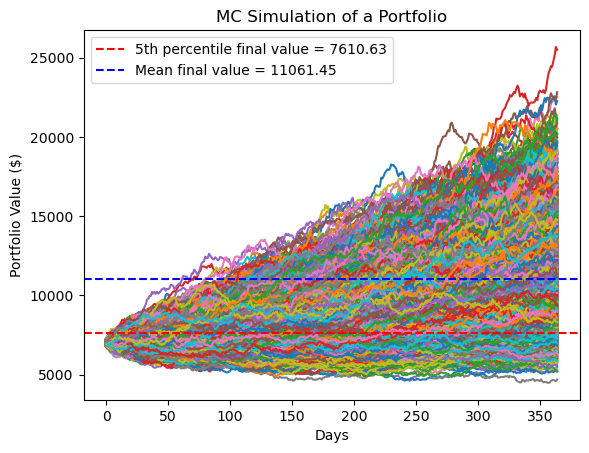

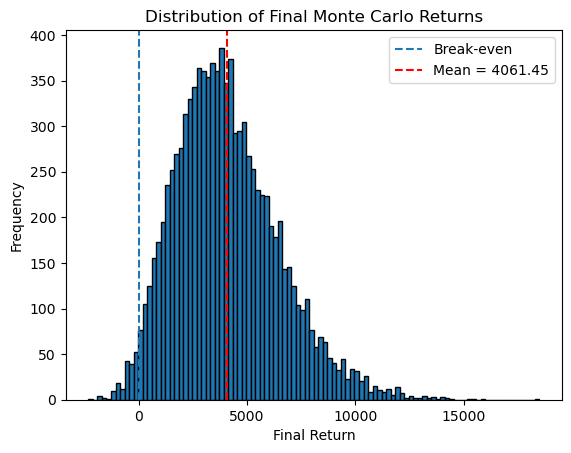

In [50]:
def plot_portfolio_results(portfolio_sims, initialPortfolio, percentile_line, mean_line, portResults, alpha=5):
    # Path plot
    plt.plot(portfolio_sims)
    plt.ylabel('Portfolio Value ($)')
    plt.xlabel('Days')
    plt.axhline(percentile_line, linestyle='--', color='r',
                label=f'{alpha}th percentile final value = {percentile_line:.2f}')
    plt.axhline(mean_line, linestyle='--', color='b',
                label=f'Mean final value = {mean_line:.2f}')
    plt.title('MC Simulation of a Portfolio')
    plt.legend()
    plt.show()

    # Histogram
    final_returns = portResults - initialPortfolio
    mean_return = final_returns.mean()
    mc_sims = portfolio_sims.shape[1]

    plt.hist(final_returns, bins=int(math.sqrt(mc_sims)), edgecolor='black')
    plt.axvline(0, linestyle='--', label='Break-even')
    plt.axvline(mean_return, linestyle='--', color='r',
                label=f'Mean = {round(mean_return, 2)}')

    plt.xlabel("Final Return")
    plt.ylabel("Frequency")
    plt.title("Distribution of Final Monte Carlo Returns")
    plt.legend()
    plt.show()

plot_portfolio_results(portfolio_sims, initialPortfolio, stats['percentile_line'], stats['mean_line'], stats['portResults'], alpha=5)

<h1>Optimizing Portfolio Weights<h2>

In [31]:
from scipy.optimize import minimize

In [32]:
w0 = np.array([5.87, 8.56, 5.09, 11.96, 15.28, 21.4, 31.63]) / 100
w0 = w0 / np.sum(w0)
L = np.linalg.cholesky(covMatrix)
Z_fixed = np.random.normal(size=(mc_sims, T, len(stockList)))


In [33]:
def objective(weights, meanReturns, L, Z_fixed, initialPortfolio, lam):
    weights = np.array(weights)
    weights = np.clip(weights, 0, 1)
    weights = weights / np.sum(weights)

    terminal_values = np.zeros(Z_fixed.shape[0])

    for m in range(Z_fixed.shape[0]):
        dailyReturns = meanReturns.values + Z_fixed[m] @ L.T
        portfolio_path = np.cumprod(dailyReturns @ weights + 1) * initialPortfolio
        terminal_values[m] = portfolio_path[-1]

    portResults = pd.Series(terminal_values)

    expected_WT = portResults.mean()
    cvar_wealth = mcCVaR(portResults, alpha=5)
    cvar_loss = initialPortfolio - cvar_wealth

    return -(expected_WT - lam * cvar_loss)

In [51]:
lam = 1.0
n_assets = len(stockList)

constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
bounds = [(0, 0.4) for _ in range(n_assets)]
result = minimize(
    objective,
    w0,
    args=(meanReturns, L, Z_fixed, initialPortfolio, lam),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

opt_weights = result.x / np.sum(result.x)
print("\nOptimal Weights (%):")
for stock, w in zip(stockList, opt_weights):
    print(f"{stock}: {w*100:.2f}%")


Optimal Weights (%):
AMZN: 0.00%
CEG: 34.68%
NFLX: 0.00%
QQQI: 0.00%
SPYG: 25.32%
VXUS: 0.00%
VTI: 40.00%


VaR $-535.41
CVaR $281.48
Mean $12680.39
Standard deviation $3807.05
Expected Total Return $5680.39
Expected Percent Return 81.15%
Expected Percent of Making a Profit 97.32%


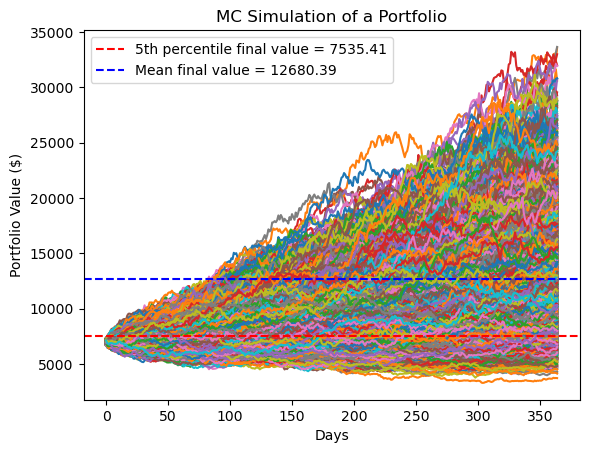

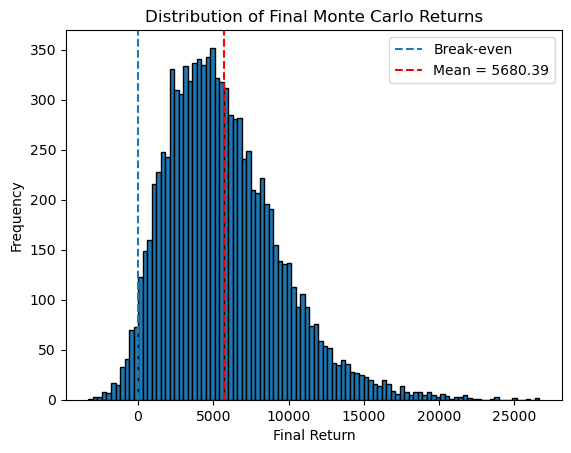

In [52]:
portfolio_sims = np.full(shape=(T, mc_sims), fill_value=0.0)

for m in range(mc_sims):
    Z = np.random.normal(size=(T, len(opt_weights)))
    dailyReturns = meanM + np.inner(L, Z)
    portfolio_sims[:, m] = np.cumprod(np.inner(opt_weights, dailyReturns.T) + 1) * initialPortfolio

portResults = pd.Series(portfolio_sims[-1, :])

stats = print_portfolio_stats(portfolio_sims, initialPortfolio, alpha=5)
plot_portfolio_results(portfolio_sims, initialPortfolio, stats['percentile_line'], stats['mean_line'], stats['portResults'], alpha=5)
